# Лабораторна Робота №2
**Тема:** Базові моделі машинного навчання для зображень

In [7]:
import os
import time
import csv
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import mnist, cifar10
from tensorflow.keras.utils import to_categorical

In [8]:
output_dir = 'output_lab2'
os.makedirs(output_dir, exist_ok=True)

## 1. Навчання простого класифікатора зображень (MNIST)
### 1.1 - 1.2 Завантаження та попередня обробка

In [9]:
(x_train_full, y_train_full), (x_test_full, y_test_full) = mnist.load_data()

x_flat = x_train_full.reshape((x_train_full.shape[0], -1))
x_test_flat = x_test_full.reshape((x_test_full.shape[0], -1))

x_norm = x_flat.astype("float32") / 255.0
x_test_norm = x_test_flat.astype("float32") / 255.0

x_train, x_val, y_train, y_val = train_test_split(
    x_norm, y_train_full, test_size=0.2, random_state=42
)

print(x_train.shape)
print(x_test_norm.shape)

(48000, 784)
(10000, 784)


### 1.3.1 Логістична регресія

In [10]:
scaler = StandardScaler(with_mean=False)
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test_norm)

clf_logreg = LogisticRegression(
    solver="saga",
    max_iter=200, 
    n_jobs=-1, 
    verbose=0
)

start_time = time.time()
clf_logreg.fit(x_train_scaled, y_train)
logreg_time = time.time() - start_time

y_pred_logreg = clf_logreg.predict(x_test_scaled)
acc_logreg = np.mean(y_pred_logreg == y_test_full)

print(f"LogisticRegression: {acc_logreg:.4f}")
print(f"{logreg_time:.2f} sec")

d:\workspace\uni\Masters\CV\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


LogisticRegression: 0.9251
312.55 sec


d:\workspace\uni\Masters\CV\.venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


### 1.3.2 Одношаровий MLP у Keras

MLP: 0.9743


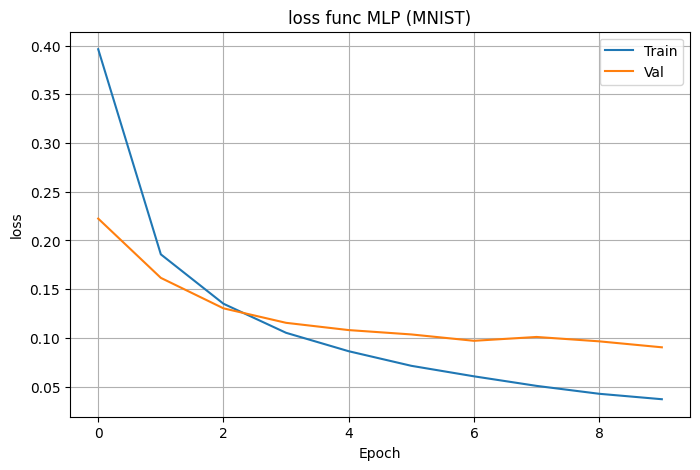

In [11]:
model_mlp = keras.Sequential([
    layers.Input(shape=(784,)),
    layers.Dense(128, activation="relu"),
    layers.Dense(10, activation="softmax")
])

model_mlp.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_mlp = model_mlp.fit(
    x_train, y_train,
    epochs=10, batch_size=128,
    validation_data=(x_val, y_val),
    verbose=0
)

test_loss_mlp, test_acc_mlp = model_mlp.evaluate(x_test_norm, y_test_full, verbose=0)
print(f"MLP: {test_acc_mlp:.4f}")

plt.figure(figsize=(8, 5))
plt.plot(history_mlp.history['loss'], label='Train')
plt.plot(history_mlp.history['val_loss'], label='Val')
plt.title('loss func MLP (MNIST)')
plt.xlabel('Epoch')
plt.ylabel('loss')
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(output_dir, 'mnist_mlp_loss.png'), dpi=150)
plt.show()

### 1.5 Порівняння класичних моделей (KNN vs SVM)

In [12]:
models = {
    "KNN(k=3)": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", KNeighborsClassifier(n_neighbors=3))
    ]),
    "SVM(Linear)": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LinearSVC(C=1.0, random_state=42, max_iter=1000, dual=False))
    ])
}

results = {}
for name, pipe in models.items():
    print(f"Тренування {name}...")
    t0 = time.time()
    pipe.fit(x_train[:10000], y_train[:10000])
    train_time = time.time() - t0
    
    t0 = time.time()
    y_pred = pipe.predict(x_test_norm)
    pred_time = time.time() - t0
    
    acc = np.mean(y_pred == y_test_full)
    results[name] = (acc, train_time, pred_time)
    print(f"{name}: Accuracy={acc:.4f}, train={train_time:.2f} sec, prediction={pred_time:.2f} sec")

Тренування KNN(k=3)...
KNN(k=3): Accuracy=0.9137, train=0.11 sec, prediction=3.34 sec
Тренування SVM(Linear)...
SVM(Linear): Accuracy=0.8723, train=223.86 sec, prediction=0.06 sec


d:\workspace\uni\Masters\CV\.venv\Lib\site-packages\sklearn\svm\_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


## 2. Побудова та тренування простого CNN для CIFAR-10
### 2.1 - 2.3 Підготовка даних, архітектура та навчання CNN

In [13]:
(x_train_c10, y_train_c10), (x_test_c10, y_test_c10) = cifar10.load_data()

x_train_c10 = x_train_c10.astype("float32") / 255.0
x_test_c10 = x_test_c10.astype("float32") / 255.0

y_train_cat = to_categorical(y_train_c10, 10)
y_test_cat = to_categorical(y_test_c10, 10)

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 
               'dog', 'frog', 'horse', 'ship', 'truck']

model_cnn = keras.Sequential([
    layers.Input(shape=(32, 32, 3)),
    layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.25),
    layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.25),
    layers.Flatten(),
    layers.Dense(512, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(10, activation="softmax")
])

model_cnn.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

history_cnn = model_cnn.fit(
    x_train_c10, y_train_cat,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 9s 0us/step


d:\workspace\uni\Masters\CV\.venv\Lib\site-packages\keras\src\datasets\cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 31s 47ms/step - accuracy: 0.4002 - loss: 1.6347 - val_accuracy: 0.5480 - val_loss: 1.2727
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 27s 44ms/step - accuracy: 0.5601 - loss: 1.2257 - val_accuracy: 0.6390 - val_loss: 1.0153
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 31s 49ms/step - accuracy: 0.6373 - loss: 1.0279 - val_accuracy: 0.7006 - val_loss: 0.8566
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 30s 48ms/step - accuracy: 0.6788 - loss: 0.9072 - val_accuracy: 0.7269 - val_loss: 0.7888
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 28s 45ms/step - accuracy: 0.7106 - loss: 0.8221 - val_accuracy: 0.7392 - val_loss: 0.7506
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 28s 45ms/step - accuracy: 0.7329 - loss: 0.7659 - val_accuracy: 0.7426 - val_loss: 0.7315
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 30s 47ms/step - accuracy: 0.7447 - loss: 0.7242 - val_accuracy: 0.7521 - val_loss: 0.7055
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 29s 47ms/step - accuracy: 0.7620 - loss: 0.6760 - 

### 2.4 Збереження моделі та результатів оцінювання

In [14]:
model_path = os.path.join(output_dir, "cifar10_cnn_model.keras")
model_cnn.save(model_path)

train_loss, train_acc = model_cnn.evaluate(x_train_c10, y_train_cat, verbose=0)
test_loss, test_acc = model_cnn.evaluate(x_test_c10, y_test_cat, verbose=0)

csv_path = os.path.join(output_dir, "cnn_loaded_results.csv")
with open(csv_path, "w", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)
    writer.writerow(["Dataset", "Loss", "Accuracy"])
    writer.writerow(["Train", f"{train_loss:.4f}", f"{train_acc:.4f}"])
    writer.writerow(["Test", f"{test_loss:.4f}", f"{test_acc:.4f}"])

## 3. Оцінка якості моделей 
### 3.1 Classification Report та 3.2 Матриця плутанини

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step
              precision    recall  f1-score   support

    airplane       0.74      0.83      0.78      1000
  automobile       0.86      0.90      0.88      1000
        bird       0.79      0.56      0.66      1000
         cat       0.58      0.55      0.57      1000
        deer       0.72      0.72      0.72      1000
         dog       0.66      0.72      0.68      1000
        frog       0.78      0.86      0.82      1000
       horse       0.84      0.79      0.82      1000
        ship       0.88      0.84      0.86      1000
       truck       0.82      0.89      0.85      1000

    accuracy                           0.77     10000
   macro avg       0.77      0.77      0.76     10000
weighted avg       0.77      0.77      0.76     10000



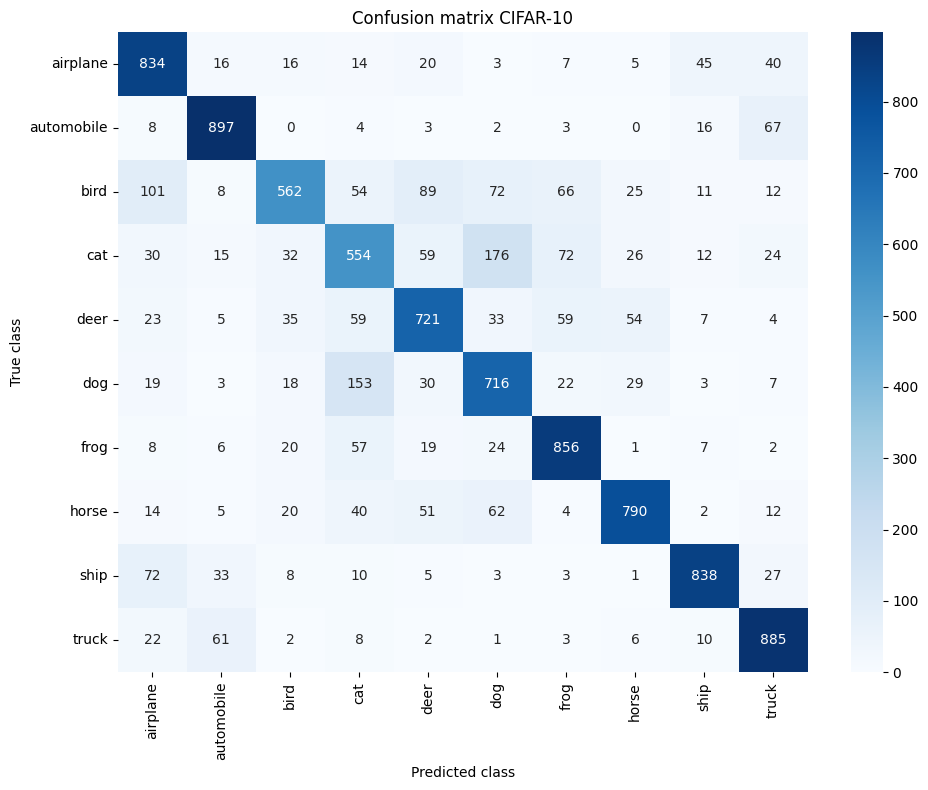

In [15]:
y_pred_probs = model_cnn.predict(x_test_c10)
y_pred_classes = np.argmax(y_pred_probs, axis=1)
y_true_classes = np.argmax(y_test_cat, axis=1)

print(classification_report(y_true_classes, y_pred_classes, target_names=class_names))

cm = confusion_matrix(y_true_classes, y_pred_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion matrix CIFAR-10')
plt.ylabel('True class')
plt.xlabel('Predicted class')
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'cifar10_confusion_matrix.png'), dpi=150)
plt.show()

### 3.3 Власне завдання: Візуалізація прикладів помилок із впевненістю моделі

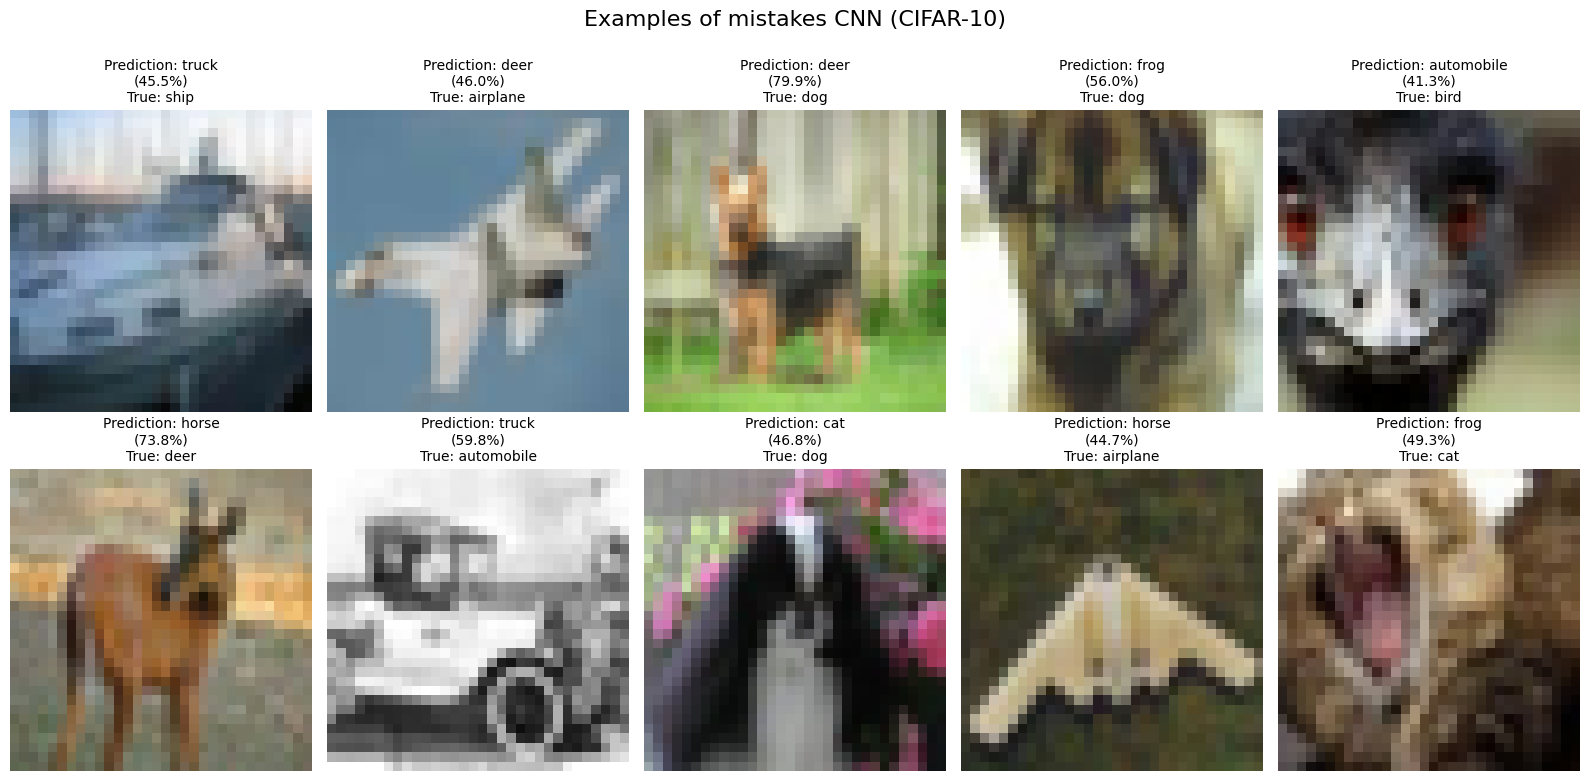

In [18]:
errors_idx = np.where(y_pred_classes != y_true_classes)[0]

plt.figure(figsize=(16, 8)) 
plt.suptitle("Examples of mistakes CNN (CIFAR-10)", fontsize=16)

for i, idx in enumerate(errors_idx[:10]):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_test_c10[idx])
    
    pred_label = class_names[y_pred_classes[idx]]
    true_label = class_names[y_true_classes[idx]]
    
    confidence = y_pred_probs[idx, y_pred_classes[idx]] * 100
    
    plt.title(f"Prediction: {pred_label}\n({confidence:.1f}%)\nTrue: {true_label}", 
              fontsize=10, color='red' if confidence > 80 else 'black')
    plt.axis('off')

plt.tight_layout(rect=[0, 0, 1, 0.95], h_pad=4.0) 

plt.savefig(os.path.join(output_dir, 'cifar10_error_analysis.png'), dpi=150)
plt.show()